
## Why Seaborn?

* provides a layer of abstraction hence simpler to use
* better aesthetics
* more graphs included

## Seaborn Roadmap

### Types of Functions

* Figure Level
* Axis Level

### Main Classification
https://seaborn.pydata.org/api.html
* Relational Plot
* Distribution Plot
* Categorical Plot
* Regression Plot
* Matrix Plot
* Multiplots

## 1 Relational Plot

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

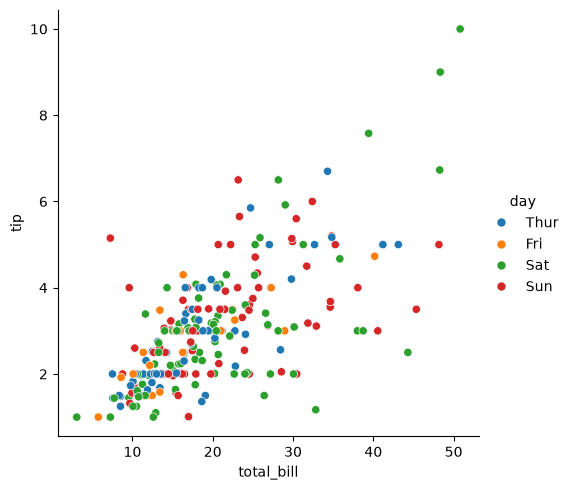

In [74]:
# relpot
tips=sns.load_dataset('tips')
sns.relplot(data=tips,x=tips['total_bill'],y=tips['tip'],hue='day')
plt.show()

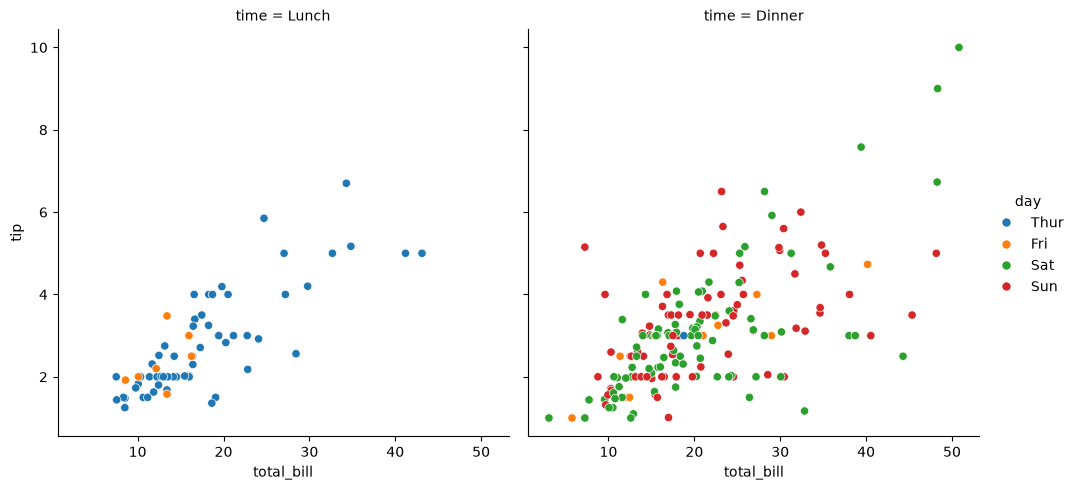

In [76]:
# adding the columns
sns.relplot(data=tips,x=tips['total_bill'],y=tips['tip'],hue='day',col='time')

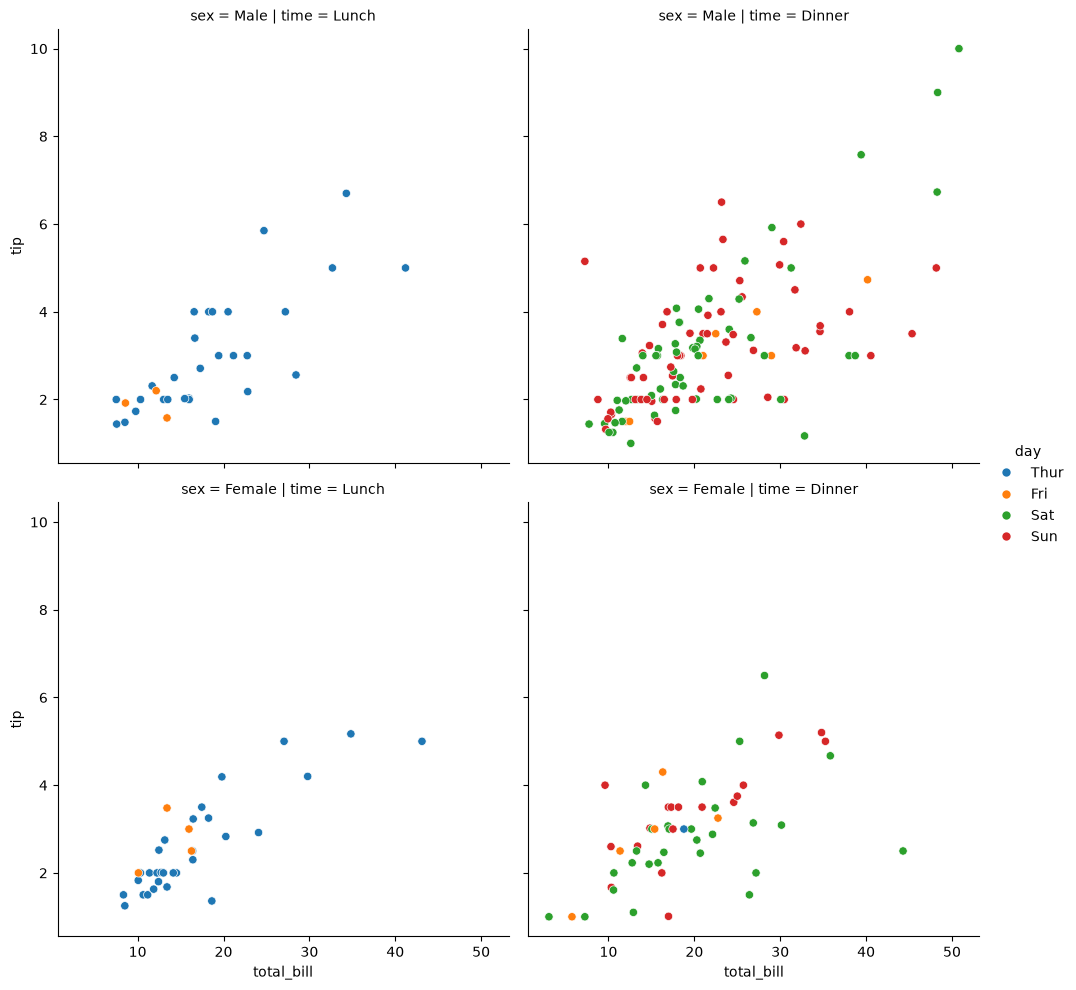

In [77]:
# adding row
sns.relplot(data=tips,x=tips['total_bill'],y=tips['tip'],hue='day',col='time',row='sex')

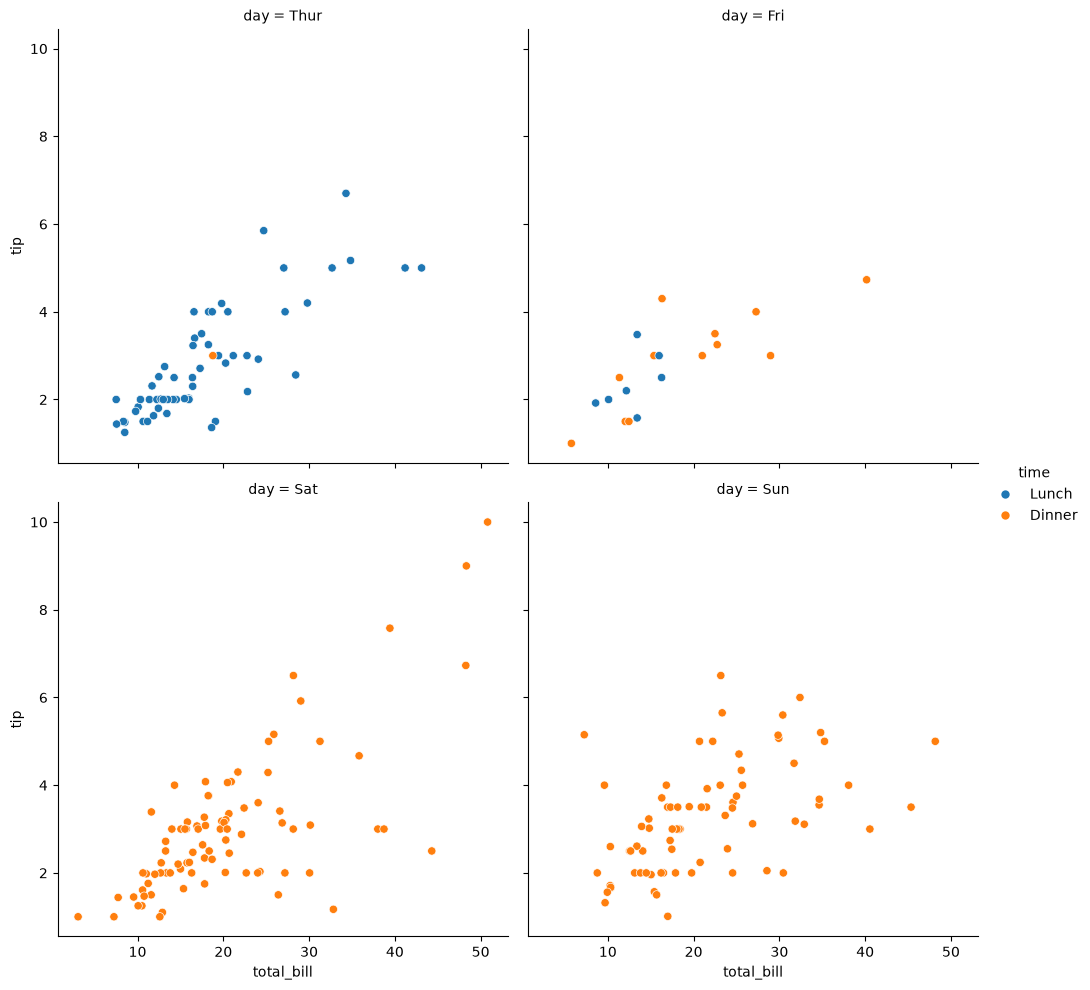

In [82]:
# When the variable assigned to col has many levels, it can be
# “wrapped” across multiple rows:
sns.relplot(data=tips,x=tips['total_bill'],y=tips['tip'],hue='time',col='day',col_wrap=2)
plt.show()

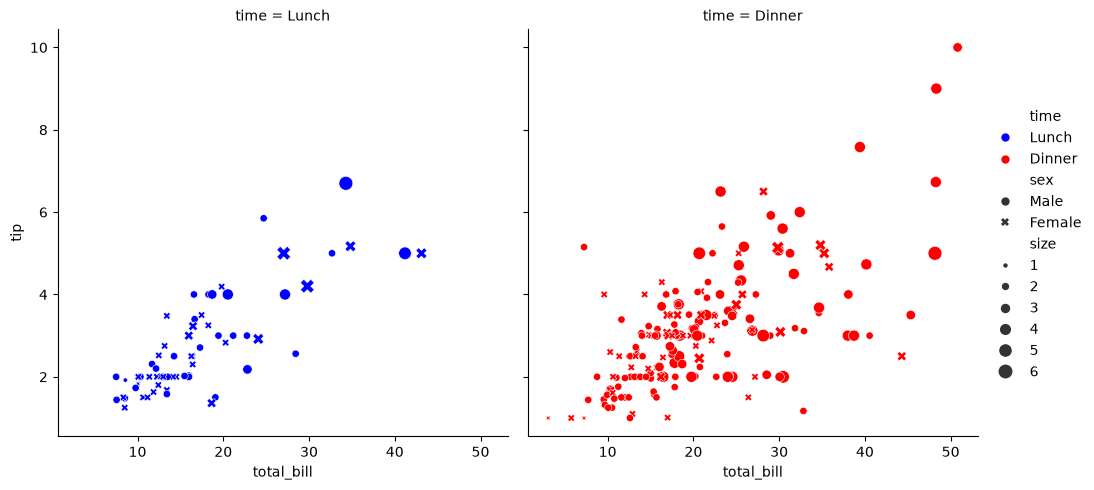

In [86]:
sns.relplot(data=tips,x=tips['total_bill'],y=tips['tip'],hue='time',col='time',size='size',palette=['b','r'],style='sex',sizes=(10, 100))
plt.show()

## 02 Scatter Plot

C:\Users\mnoma\AppData\Local\Temp\ipykernel_8332\3507954508.py:1: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(x='total_bill',y='tip',data=tips,hue='day',palette=['b','r'])


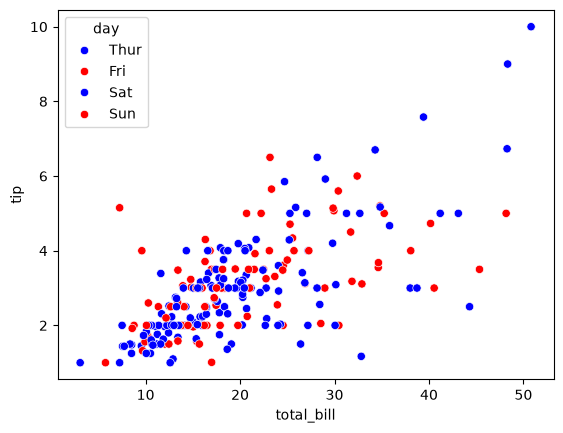

In [94]:
sns.scatterplot(x='total_bill',y='tip',data=tips,hue='day',palette=['b','r'])
plt.show()

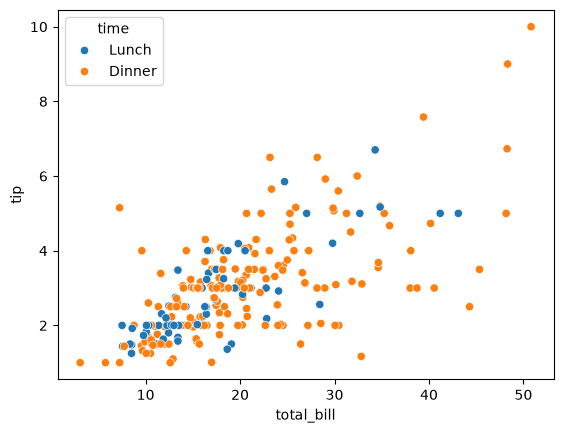

In [98]:
# hue on the basis on time
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="time")
plt.show()

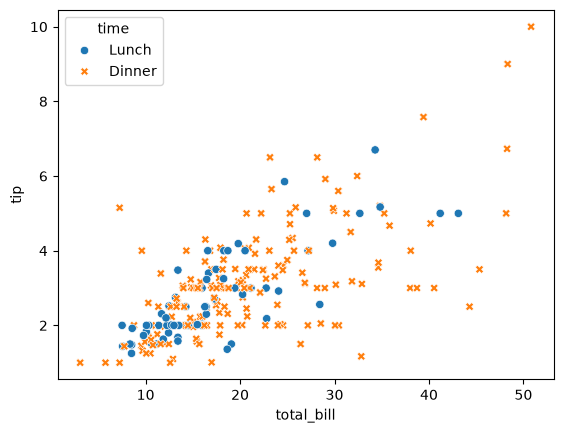

In [101]:
# style
sns.scatterplot(data=tips,x='total_bill',y='tip',hue='time',style='time')
plt.show()

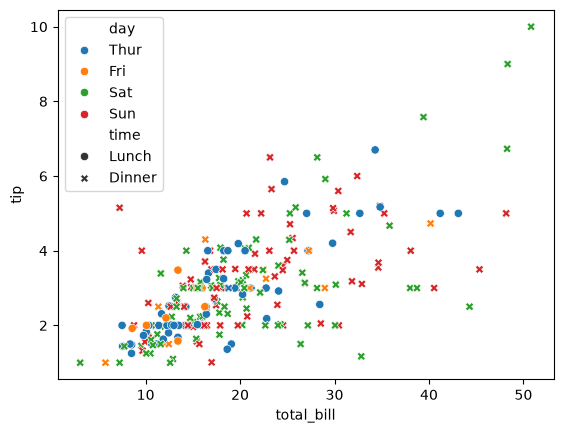

In [104]:
# hue and style
sns.scatterplot(data=tips,x='total_bill',y='tip',hue='day',style='time')
plt.show()

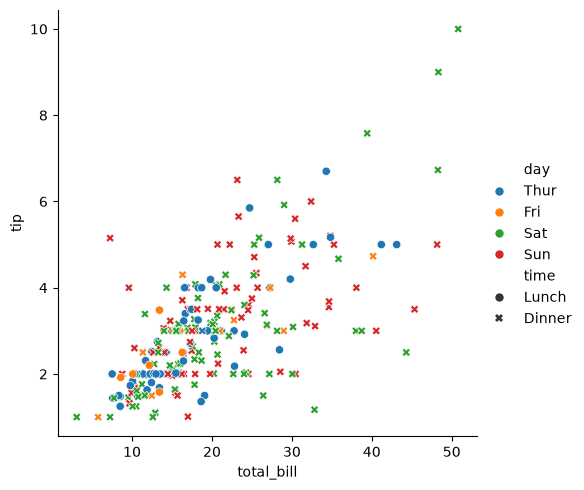

In [105]:
# same can be done
sns.relplot(data=tips,x='total_bill',y='tip',hue='day',style='time')
plt.show()

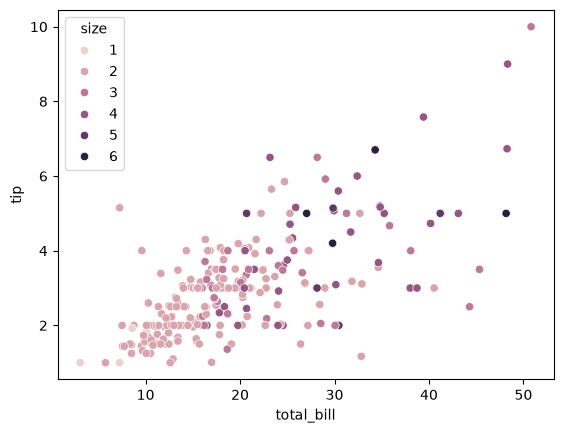

In [111]:
# If the variable assigned to hue is numeric, the semantic
# mapping will be quantitative and use a different default palette:
sns.scatterplot(data=tips,x='total_bill',y='tip',hue='size')
plt.show()

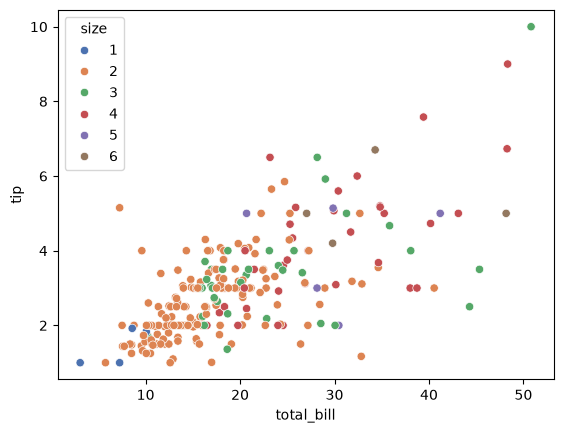

In [112]:
# Pass the name of a categorical palette or explicit colors
# (as a Python list of dictionary) to force categorical mapping 
# of the hue variable:
sns.scatterplot(data=tips,x='total_bill',y='tip',hue='size',palette='deep')
plt.show()

<Axes: xlabel='total_bill', ylabel='tip'>

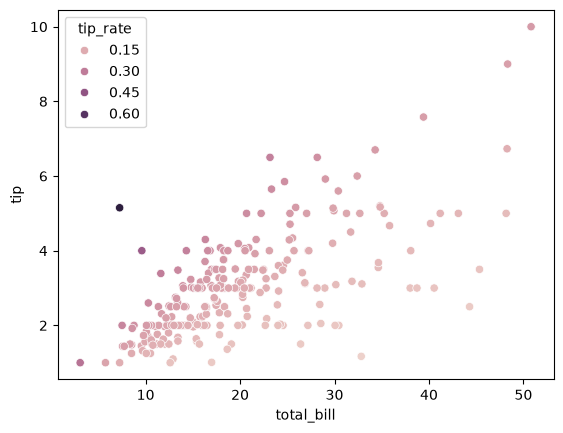

In [116]:
# If there are a large number of unique numeric values, the legend 
# will show a representative, evenly-spaced set:
tip_rate=tips.eval("tip / total_bill").rename('tip_rate')
sns.scatterplot(x='total_bill',y='tip',hue=tip_rate,data=tips)

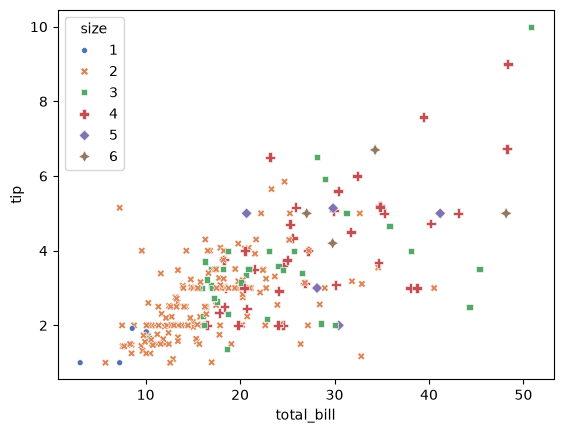

In [120]:
sns.scatterplot(x='total_bill',y='tip',hue='size',size='size',palette='deep',style='size',data=tips)
plt.show()

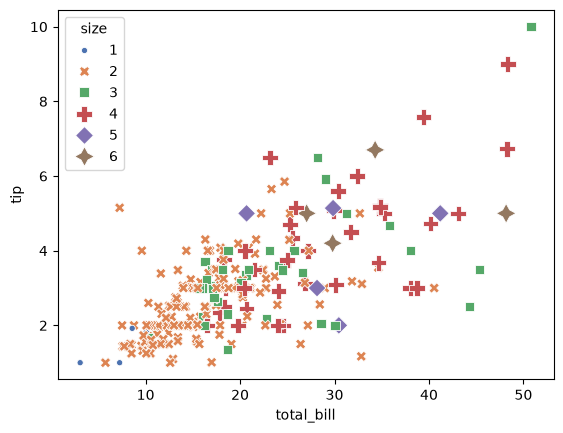

In [ ]:
# Control the range of marker areas with sizes, and set
# legend="full" to force every unique value to appear in the legend:
sns.scatterplot(x='total_bill',y='tip',hue='size',size='size',sizes=(20,200),legend="full",palette='deep',style='size',data=tips)
plt.show()

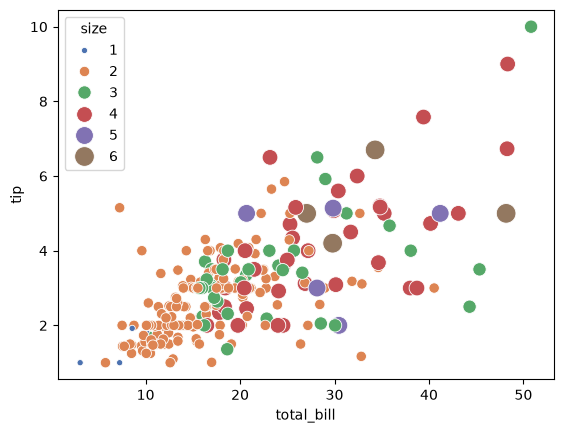

In [125]:
# Pass a tuple of values or a matplotlib.colors.
# Normalize object to hue_norm to control the quantitative hue mapping:
sns.scatterplot(x='total_bill',y='tip',hue='size',size='size',sizes=(20,200),legend="full",palette='deep',hue_norm=(0,7),data=tips)
plt.show()

<Axes: xlabel='total_bill', ylabel='tip'>

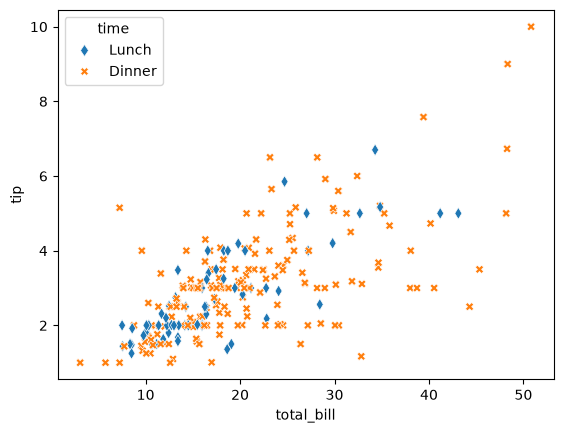

In [ ]:
# Control the specific markers used to map the style variable
# by passing a Python list or dictionary of marker codes:
markers = {"Lunch": "d", "Dinner": "X"}
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="time",style="time", markers=markers)

<Axes: xlabel='total_bill', ylabel='tip'>

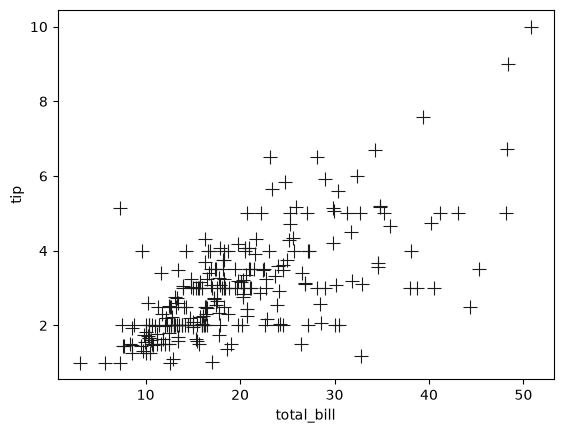

In [140]:
sns.scatterplot(data=tips, x="total_bill", y="tip", s=100, color=".1", marker="+")

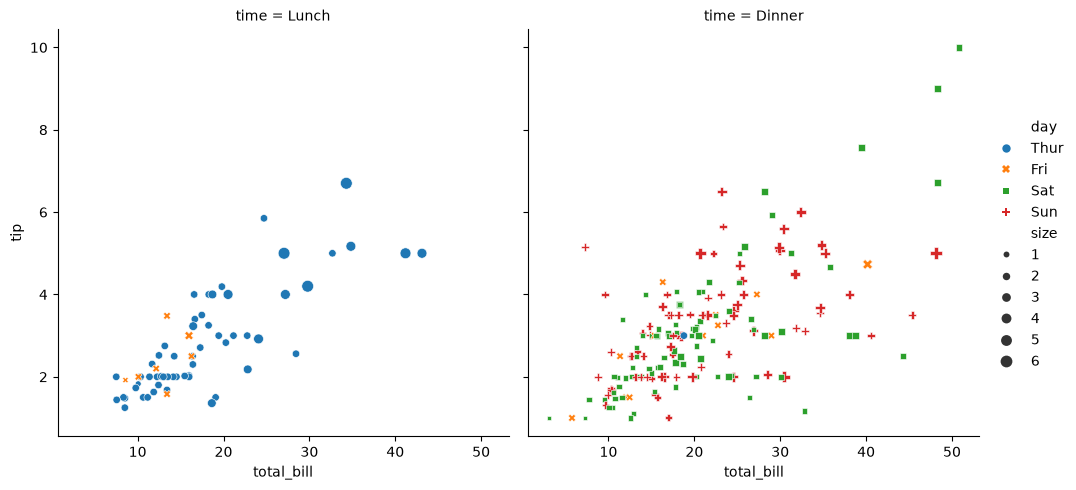

In [145]:
sns.relplot(
    data=tips, x="total_bill", y="tip",
    col='time',hue='day',style='day',size='size'
)

## 03 lineplot

In [150]:
flight=sns.load_dataset('flights')
flight.head(12)

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
5,1949,Jun,135
6,1949,Jul,148
7,1949,Aug,148
8,1949,Sep,136
9,1949,Oct,119


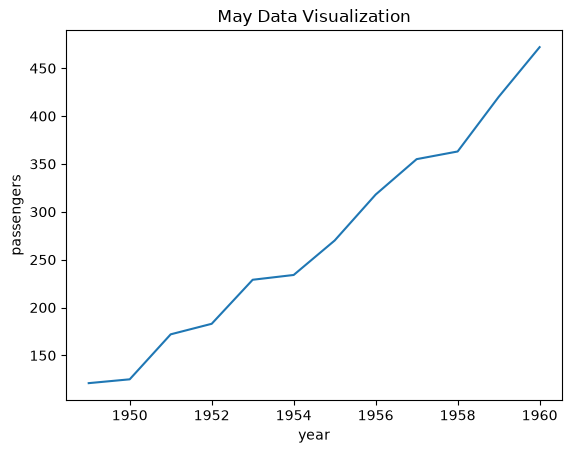

In [155]:
may_data=flight[flight['month']=='May']
may_data
sns.lineplot(data=may_data,x='year',y='passengers')
plt.title('May Data Visualization')
plt.show()

In [157]:
may_data2=flight.query("month=='May'")
may_data2

,year,month,passengers
4,1949,May,121
16,1950,May,125
28,1951,May,172
40,1952,May,183
52,1953,May,229
64,1954,May,234
76,1955,May,270
88,1956,May,318
100,1957,May,355
112,1958,May,363


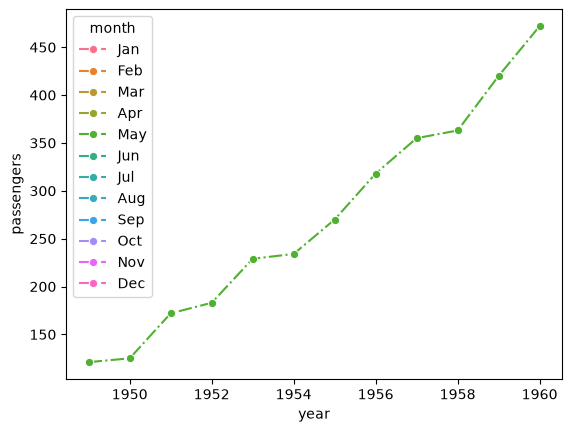

In [166]:
sns.lineplot(data=may_data2,x='year',y='passengers',linestyle='-.',marker='o',hue="month")
plt.show()

In [169]:
# Pivot the dataframe to a wide-form representation:
wide_range=flight.pivot(index='year',columns='month',values='passengers')
wide_range

month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
year,,,,,,,,,,,,
1949,112,118,132,129,121,135,148,148,136,119,104,118
1950,115,126,141,135,125,149,170,170,158,133,114,140
1951,145,150,178,163,172,178,199,199,184,162,146,166
1952,171,180,193,181,183,218,230,242,209,191,172,194
1953,196,196,236,235,229,243,264,272,237,211,180,201
1954,204,188,235,227,234,264,302,293,259,229,203,229
1955,242,233,267,269,270,315,364,347,312,274,237,278
1956,284,277,317,313,318,374,413,405,355,306,271,306
1957,315,301,356,348,355,422,465,467,404,347,305,336


<Axes: xlabel='year', ylabel='May'>

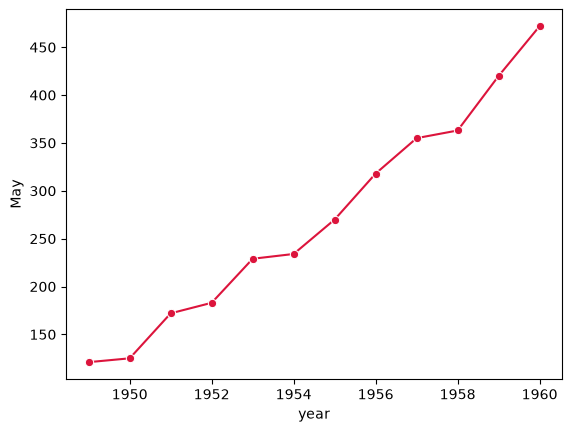

In [176]:
sns.lineplot(data=wide_range['May'],color='crimson',marker='o')

<Axes: xlabel='year', ylabel='passengers'>

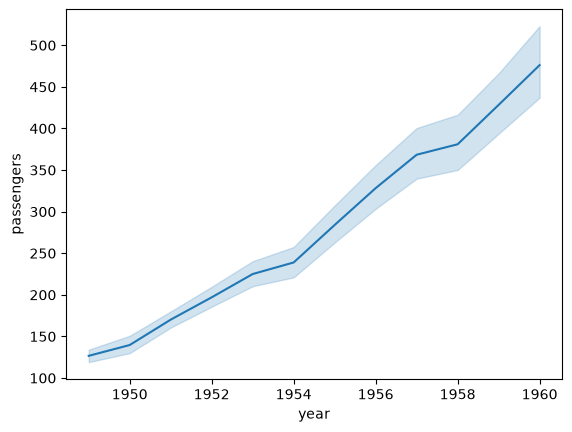

In [177]:
sns.lineplot(data=flight, x="year", y="passengers")

<Axes: xlabel='year', ylabel='passengers'>

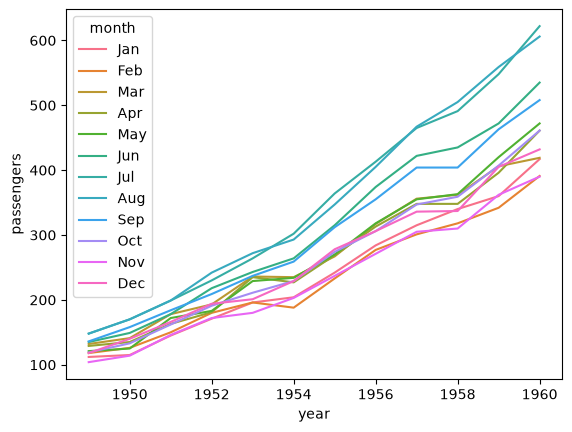

In [ ]:

sns.lineplot(data=flight,x='year',y='passengers',hue='month')

<Axes: xlabel='year', ylabel='passengers'>

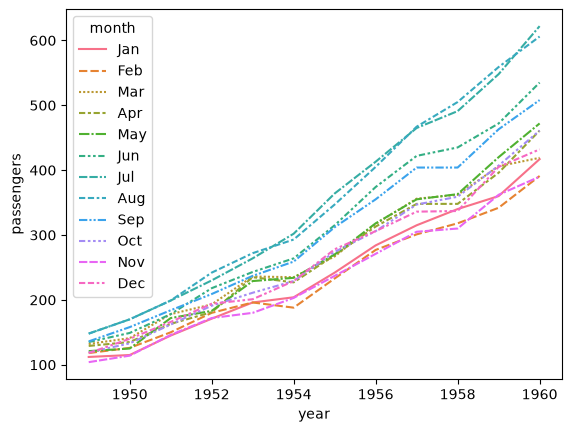

In [179]:
sns.lineplot(data=flight,x='year',y='passengers',hue='month',style='month')

<Axes: xlabel='passengers', ylabel='year'>

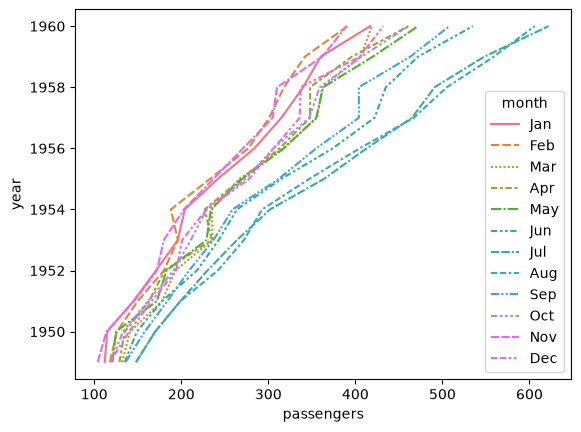

In [181]:
# Use the orient parameter to aggregate and sort along 
# the vertical dimension of the plot:
sns.lineplot(data=flight,x='passengers',y='year',hue='month',style='month',orient='y')

# Distribution Plots

## 01 Displot

In [184]:
penguins=sns.load_dataset('penguins')
penguins.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


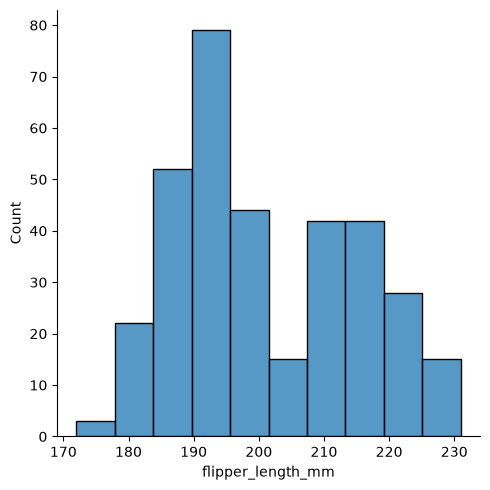

In [187]:
sns.displot(data=penguins,x='flipper_length_mm')

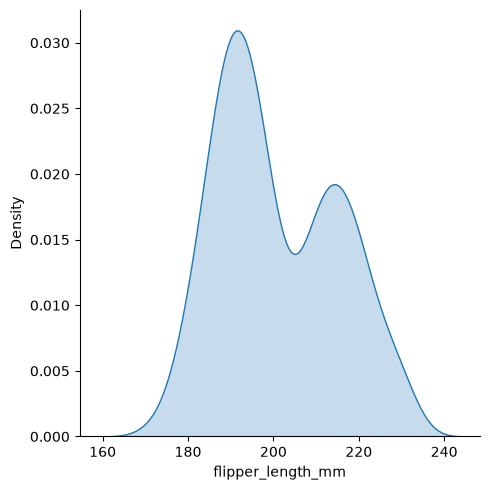

In [ ]:
# give the kind kernel density estimates (KDEs),
sns.displot(data=penguins,x='flipper_length_mm',kind='kde',fill='full')

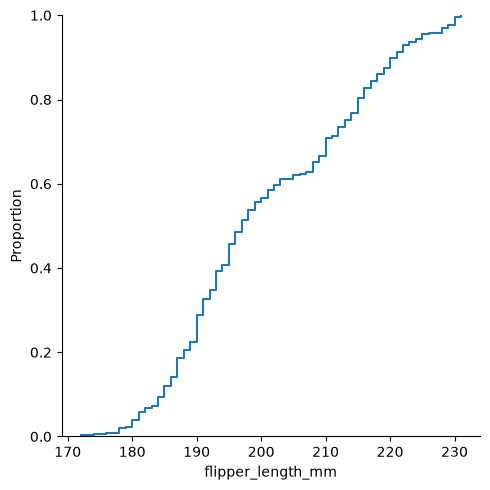

In [ ]:
# empirical cumulative distribution functions (ECDFs):
sns.displot(data=penguins,x='flipper_length_mm',kind='ecdf')

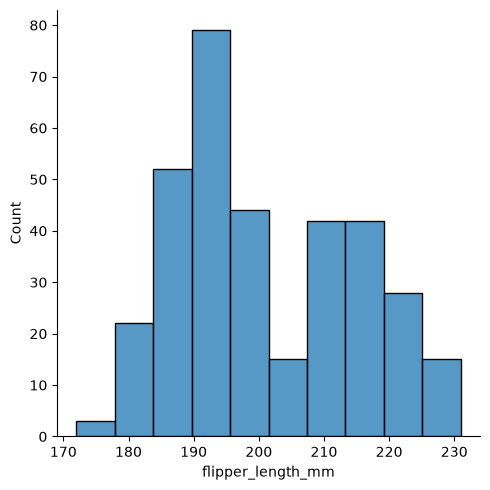

In [ ]:
# kind is histogram
sns.displot(data=penguins,x='flipper_length_mm',kind='hist')

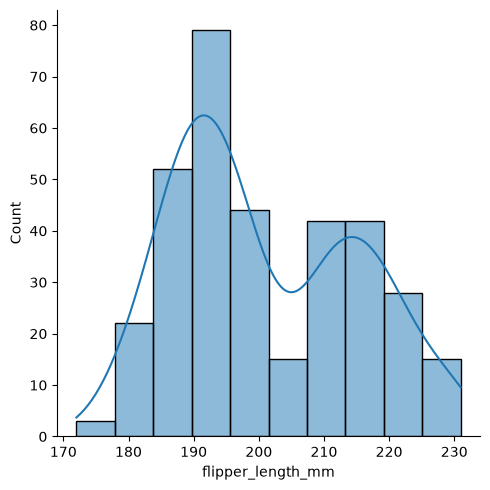

In [197]:
sns.displot(data=penguins,x='flipper_length_mm',kde=True)

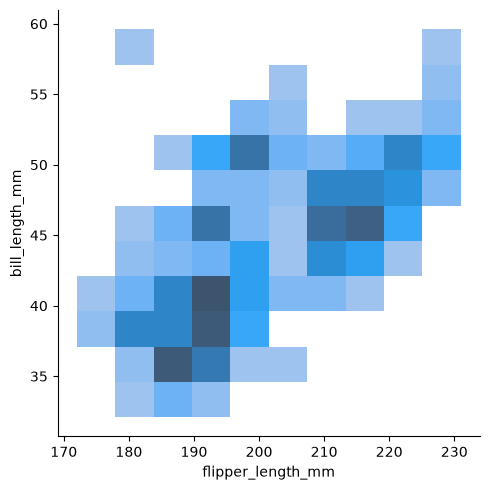

In [199]:
sns.displot(data=penguins,x='flipper_length_mm',y='bill_length_mm')

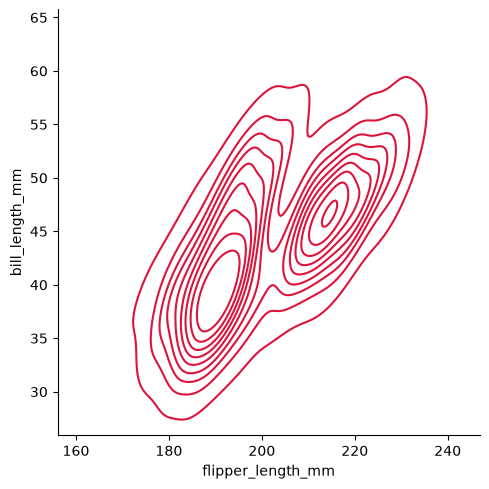

In [201]:
# Currently, bivariate plots are available only for histograms and KDEs:
sns.displot(data=penguins,x='flipper_length_mm',y='bill_length_mm',kind='kde',color='crimson')

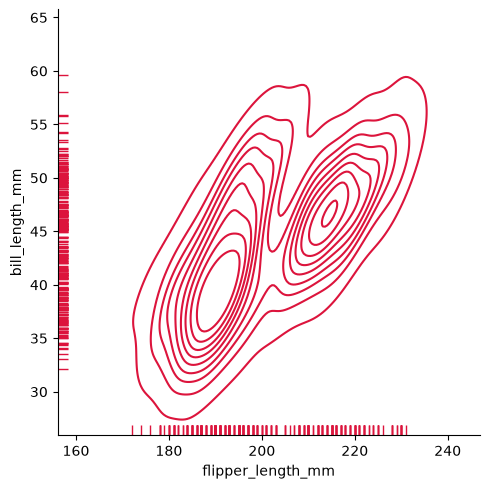

In [ ]:
# For each kind of plot, you can also show individual observations
# with a marginal “rug”:
sns.displot(data=penguins,x='flipper_length_mm',y='bill_length_mm',
            kind='kde',rug=True,color='crimson')

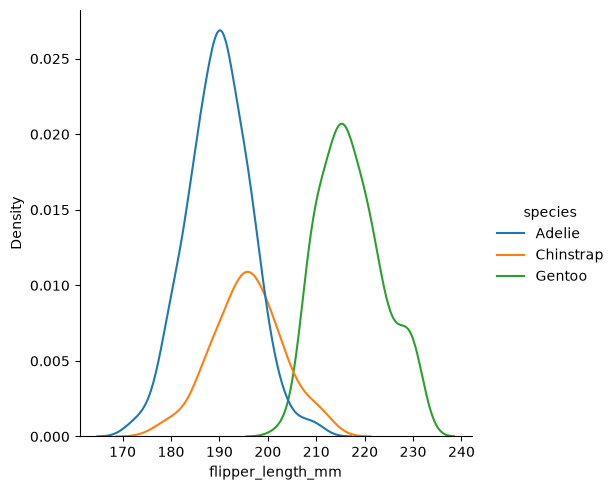

In [205]:
# Each kind of plot can be drawn separately for subsets of data 
# using hue mapping:
sns.displot(data=penguins,x='flipper_length_mm',hue='species',kind='kde')


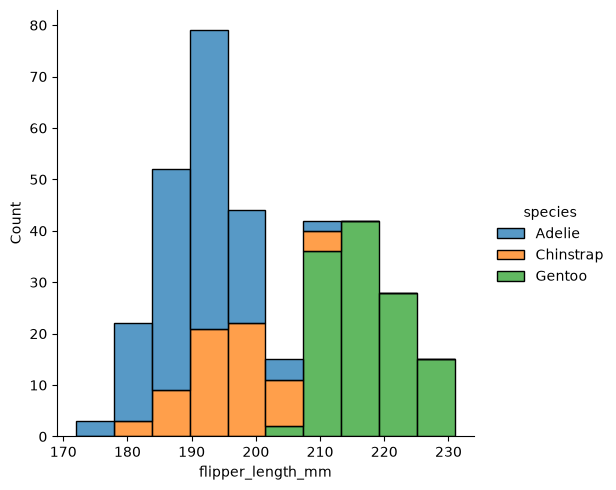

In [210]:
sns.displot(data=penguins, x="flipper_length_mm", hue="species",multiple='stack')
plt.show()

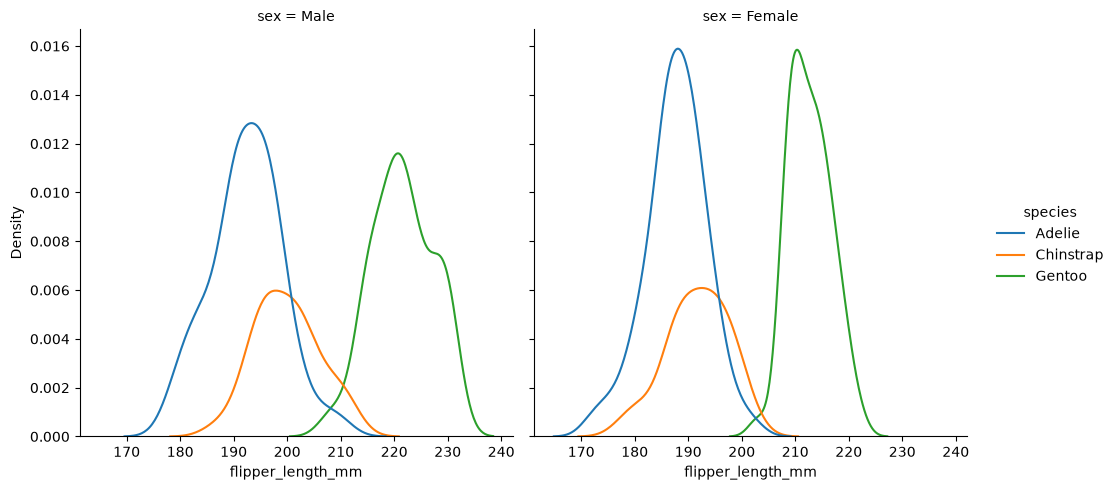

In [211]:
sns.displot(data=penguins,x="flipper_length_mm",hue='species',col='sex',kind='kde')

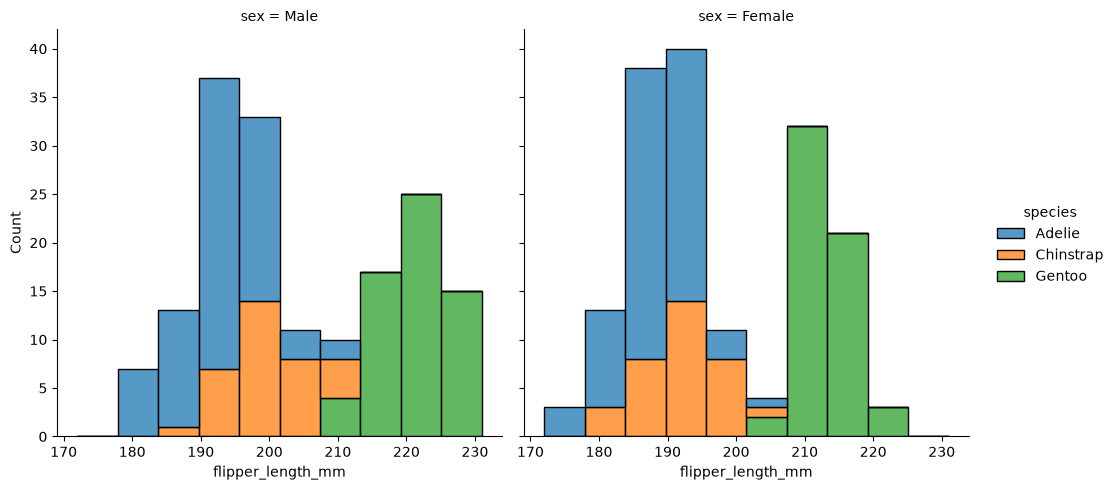

In [ ]:
sns.displot(data=penguins,x="flipper_length_mm",hue='species',
            col='sex',multiple='stack')



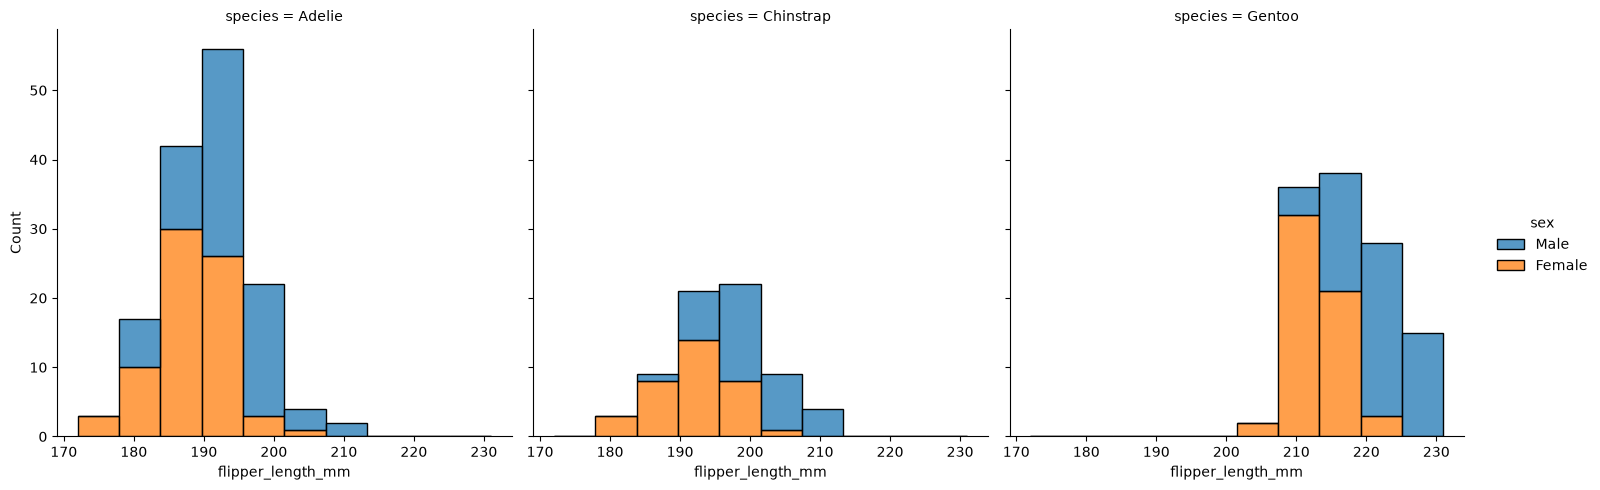

In [ ]:
sns.displot(data=penguins,x="flipper_length_mm",hue='sex',
            col='species',multiple='stack')

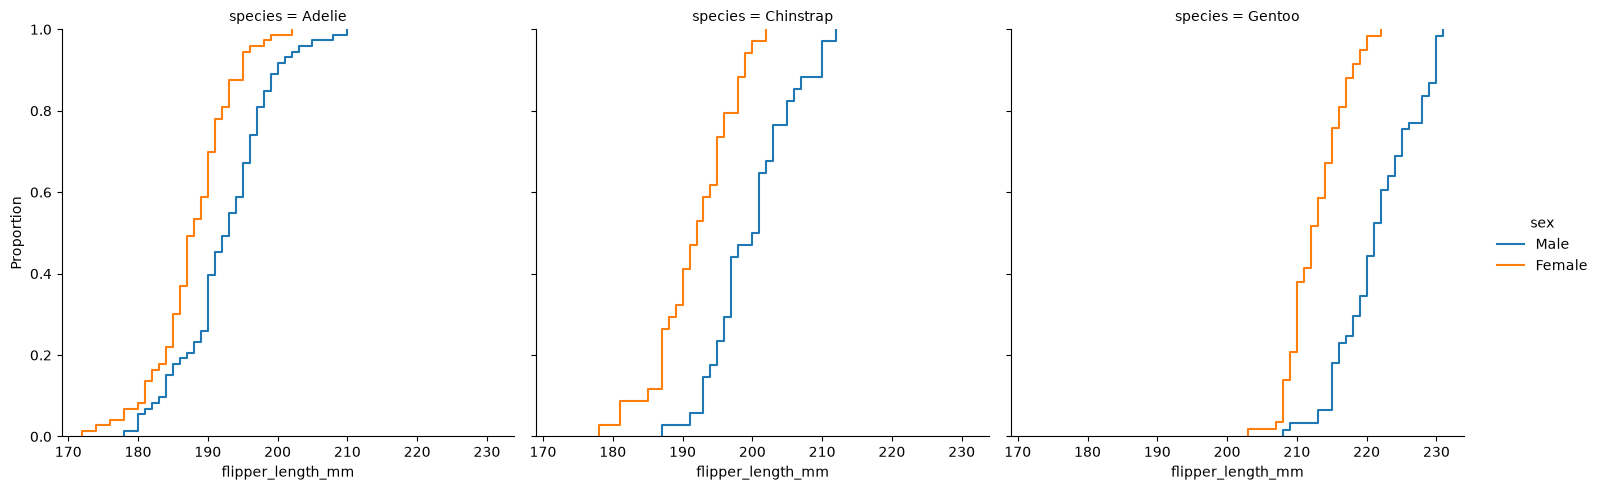

In [215]:
sns.displot(data=penguins,x="flipper_length_mm",hue='sex',
            col='species',kind='ecdf')

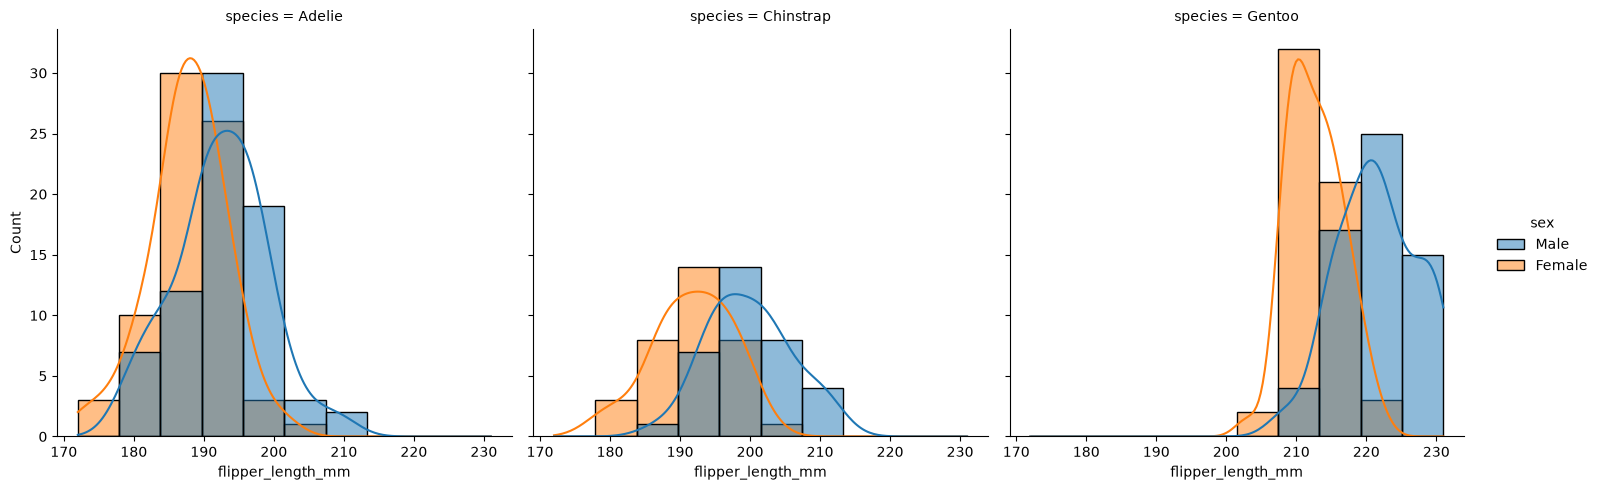

In [216]:
sns.displot(data=penguins,x="flipper_length_mm",hue='sex',
            col='species',kde=True)

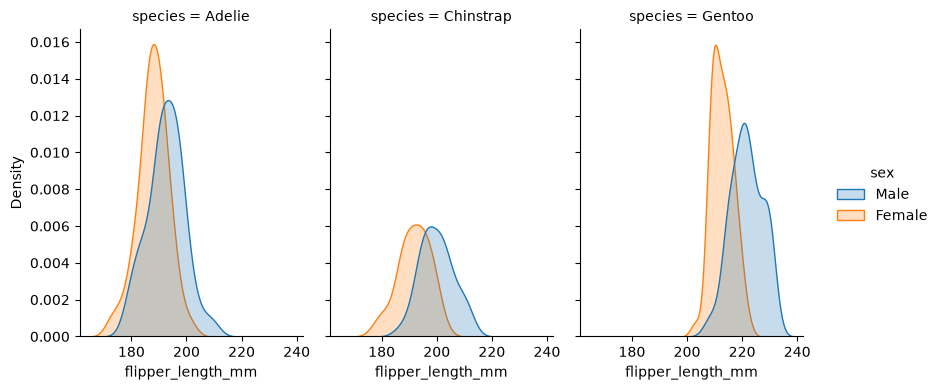

In [229]:
sns.displot(
    data=penguins, x="flipper_length_mm", hue="sex", col="species",
    kind="kde", height=4, aspect=.7,fill="full")

## 02 Histogram


<Axes: xlabel='flipper_length_mm', ylabel='Count'>

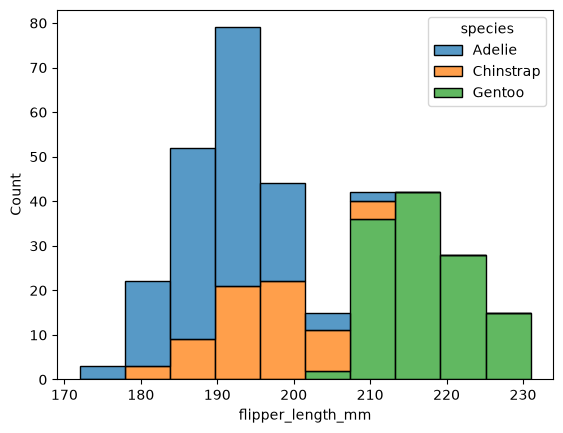

In [232]:
sns.histplot(data=penguins,x="flipper_length_mm",hue='species',multiple="stack")

<Axes: xlabel='Count', ylabel='flipper_length_mm'>

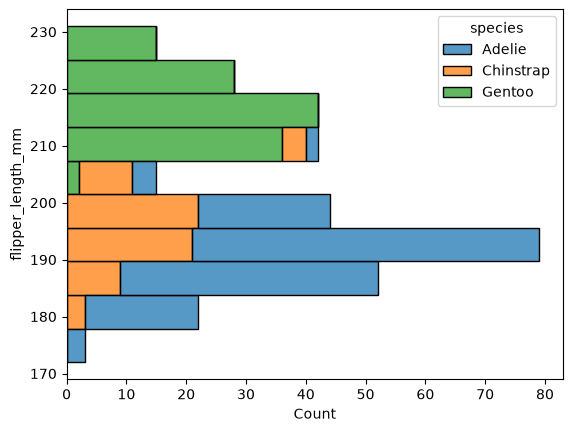

In [233]:
sns.histplot(data=penguins,y="flipper_length_mm",hue='species',multiple="stack")

<Axes: xlabel='flipper_length_mm', ylabel='Count'>

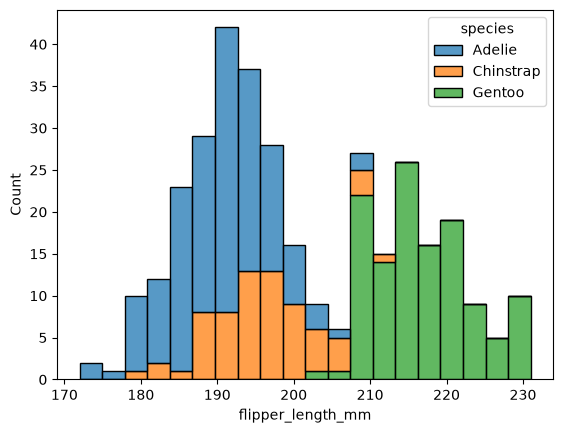

In [234]:
# Check how well the histogram represents the data by specifying
# a different bin width:
sns.histplot(data=penguins,x="flipper_length_mm",hue="species",multiple="stack",binwidth=3)

<Axes: xlabel='flipper_length_mm', ylabel='Count'>

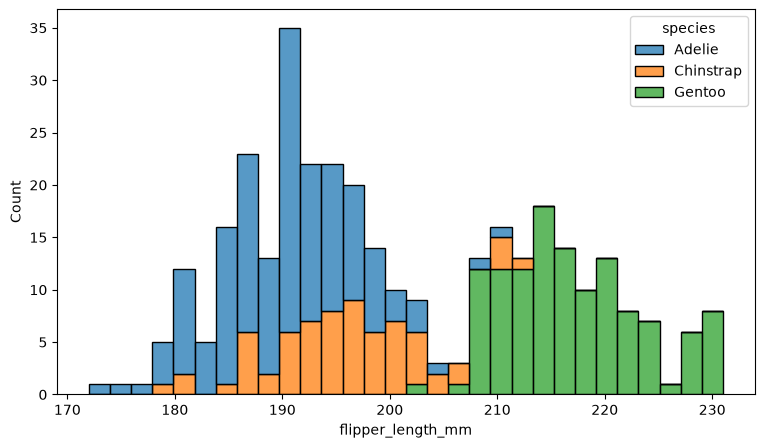

In [246]:
# You can also define the total number of bins to use
plt.figure(figsize=(9,5))
sns.histplot(data=penguins,x="flipper_length_mm",hue="species",multiple="stack",bins=30)

<Axes: xlabel='flipper_length_mm', ylabel='Count'>

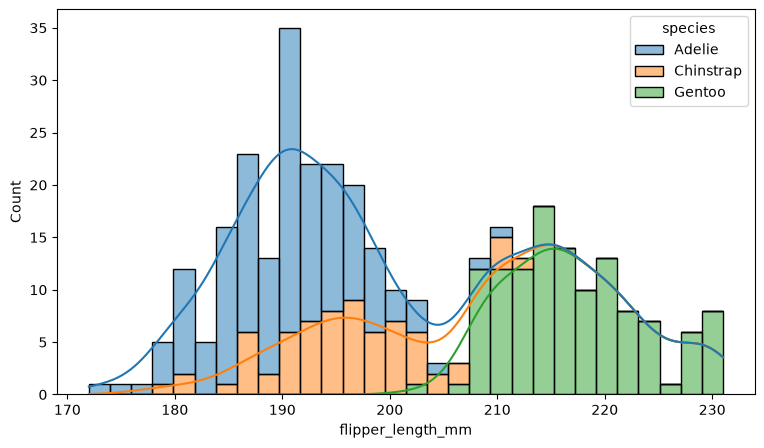

In [247]:
# adding kde
plt.figure(figsize=(9,5))
sns.histplot(data=penguins,x="flipper_length_mm",hue="species",multiple="stack",bins=30,kde=True)

<Axes: ylabel='Count'>

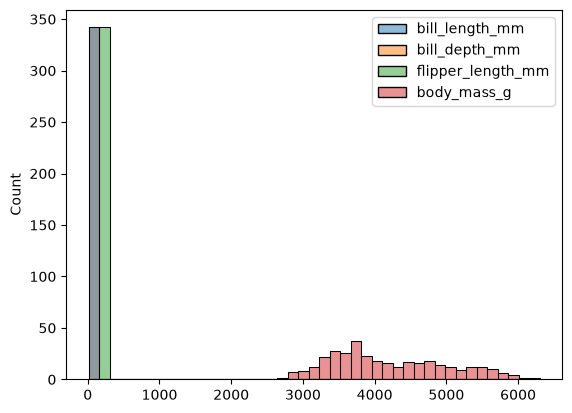

In [248]:
# If neither x nor y is assigned, the dataset is treated
# as wide-form, and a histogram is drawn for each numeric column:
sns.histplot(data=penguins)

<Axes: xlabel='flipper_length_mm', ylabel='Count'>

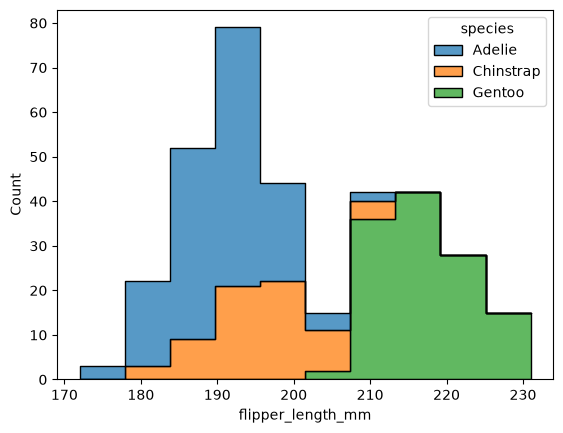

In [ ]:
# Overlapping bars can be hard to visually resolve. A different 
# approach would be to draw a step function:
sns.histplot(data=penguins,x="flipper_length_mm",hue="species",multiple="stack",element="step")

You can move even farther away from bars by drawing a polygon with vertices in the center of each bin. This may make it easier to see the shape of the distribution, but use with caution: it will be less obvious to your audience that they are looking at a histogram:

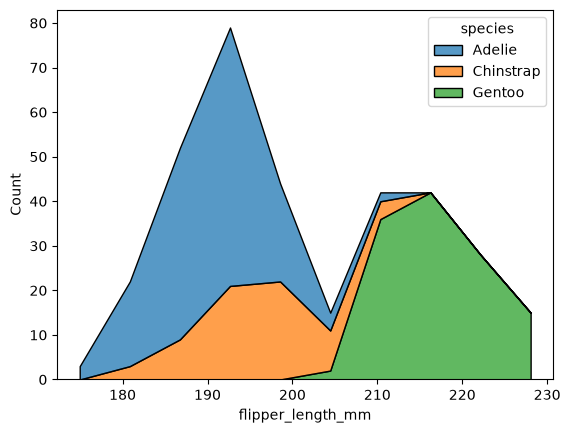

In [252]:
sns.histplot(data=penguins,x="flipper_length_mm",hue="species",multiple="stack",element="poly")
plt.show()

## Data Visualization with Seaborn

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [72]:
tips=sns.load_dataset('tips')
tips.head(5)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Scatter plot

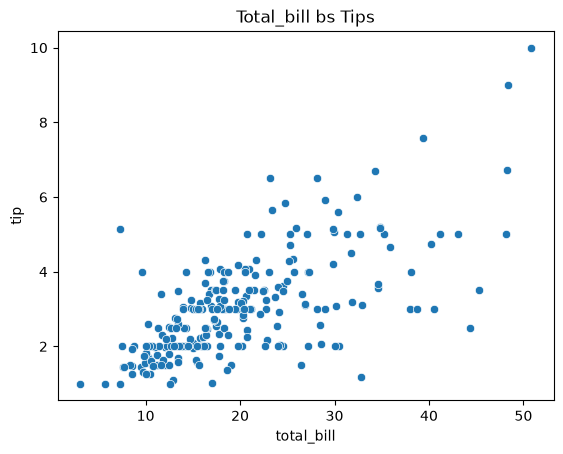

In [10]:
sns.scatterplot(x='total_bill',y='tip',data=tips)
plt.title('Total_bill bs Tips')
plt.show()

## Lineplot

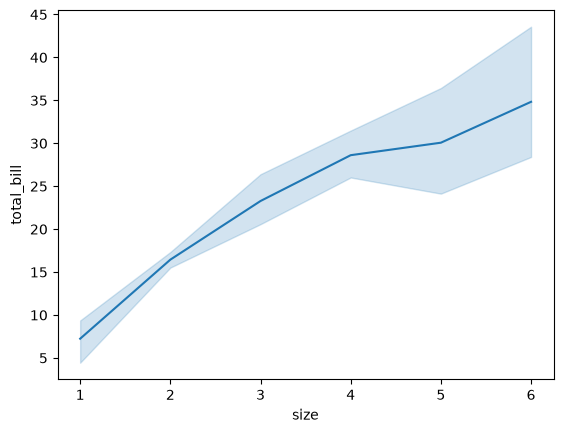

In [12]:
sns.lineplot(x='size',y='total_bill',data=tips)
plt.show()

## Barplot

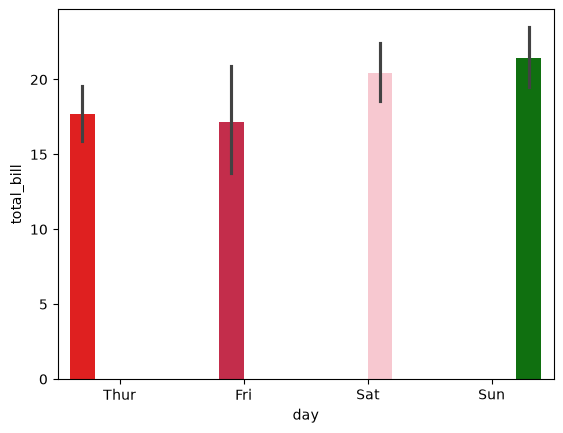

In [21]:
# Bar chart
colors = ['red', 'crimson', 'pink', 'green']
sns.barplot(x='day',y='total_bill',data=tips,hue='day',palette=colors,legend=False)
plt.show()


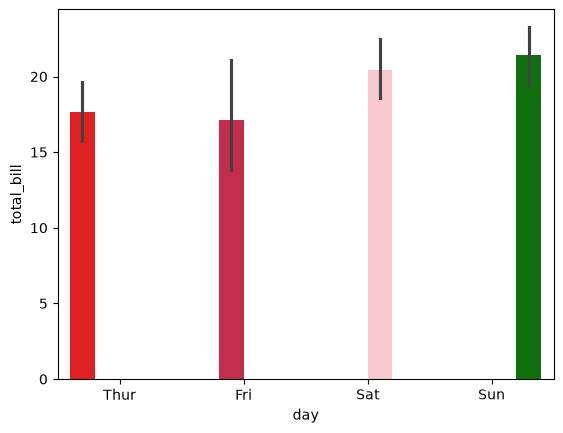

In [23]:
# Bar chart
colors = ['red', 'crimson', 'pink', 'green']
sns.barplot(x=tips['day'],y=tips['total_bill'],data=tips,hue=tips['day'],palette=colors)
plt.show()


## Boxplot

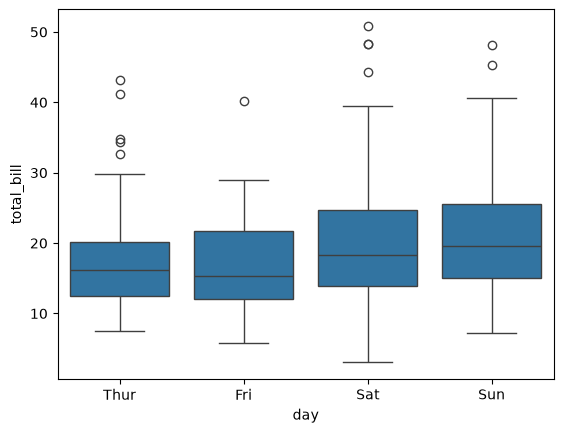

In [28]:
sns.boxplot(x=tips['day'],y=tips['total_bill'])
plt.show()

## violinplot

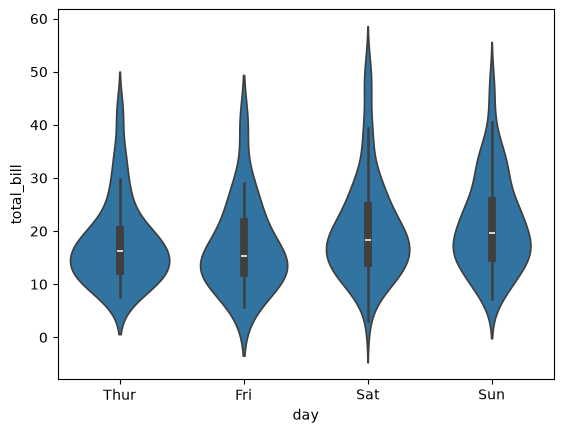

In [32]:
# colors = ['red', 'crimson', 'pink', 'green']
sns.violinplot(x=tips['day'],y=tips['total_bill'],data=tips)
plt.show()

## Histogram

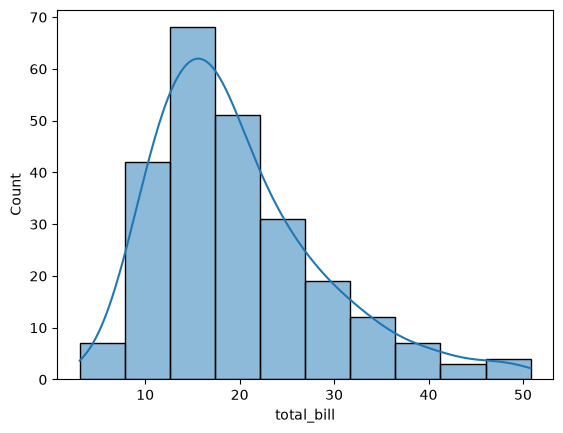

In [34]:
sns.histplot(tips['total_bill'],bins=10,kde=True)
plt.show()

## KDE Graph

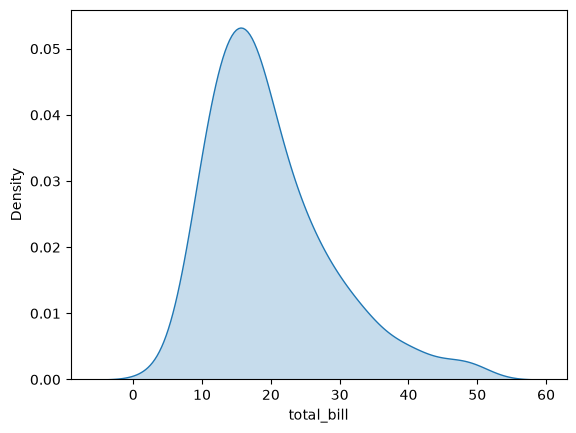

In [37]:
sns.kdeplot(tips['total_bill'],fill=True)
plt.show()

## Pairplot

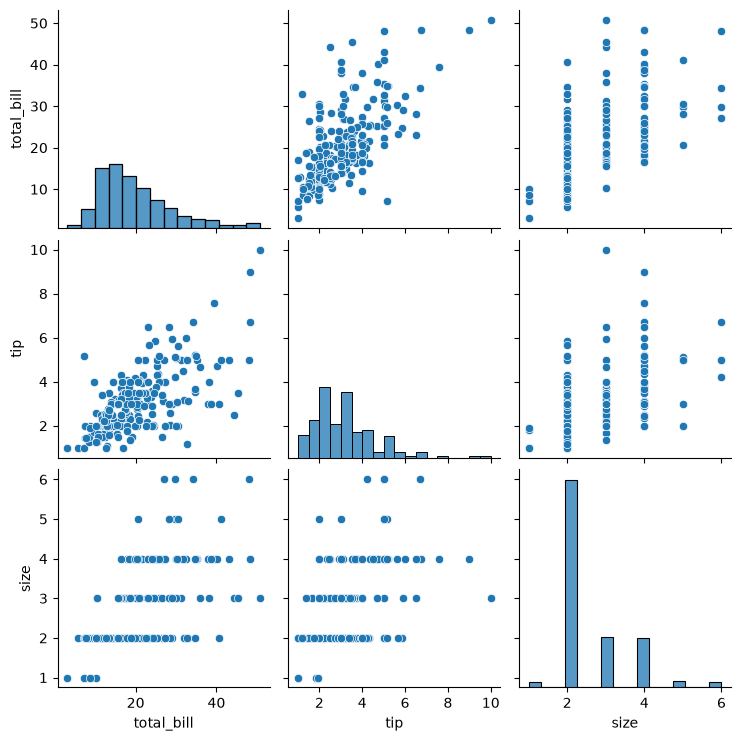

In [38]:
sns.pairplot(tips)

## Heatmap

In [39]:
corr=tips[['total_bill','tip','size']].corr()
corr

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


<Axes: >

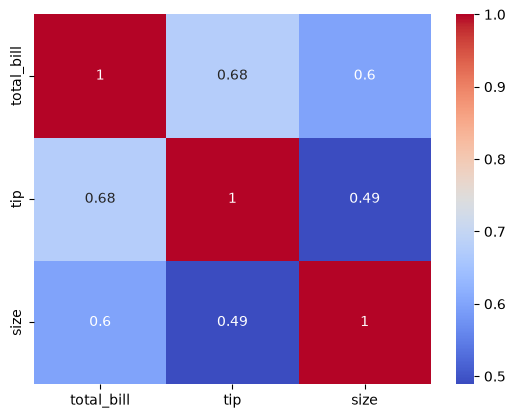

In [40]:
sns.heatmap(corr,annot=True,cmap='coolwarm')

In [43]:
sales=pd.read_csv('sales_transactions.csv')
sales.head(5)

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal


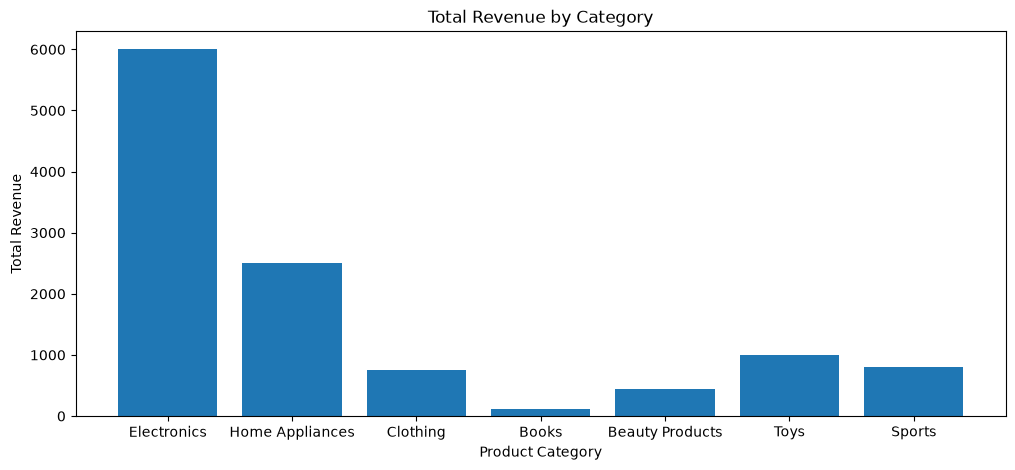

In [55]:
plt.figure(figsize=(12,5))
plt.bar(sales['Product Category'],sales['Total Revenue'])
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.title('Total Revenue by Category')
plt.show()

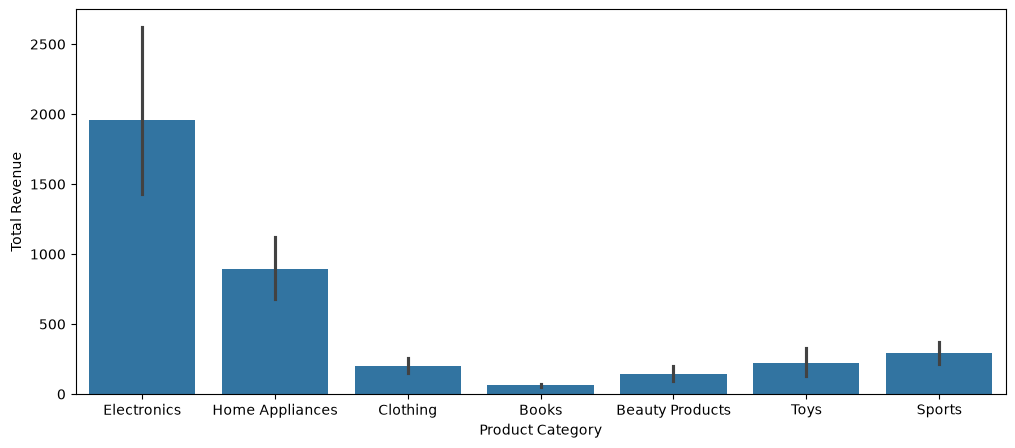

In [52]:
# same in seaborn
plt.figure(figsize=(12,5))
sns.barplot(x=sales['Product Category'],y=sales['Total Revenue'],data=sales)
plt.show()

<Axes: >

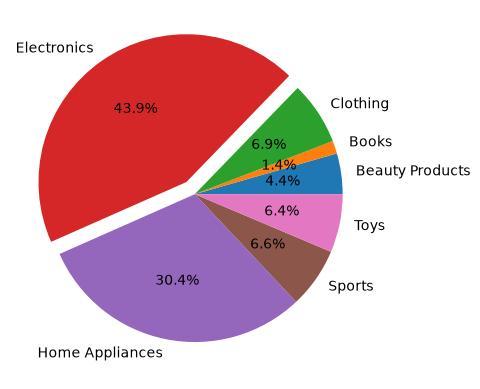

In [64]:
sales.groupby('Product Category')['Total Revenue'].sum().plot(kind='pie',autopct='%1.1f%%',explode=[0,0,0,0.1,0,0,0])

<Axes: xlabel='Product Category'>

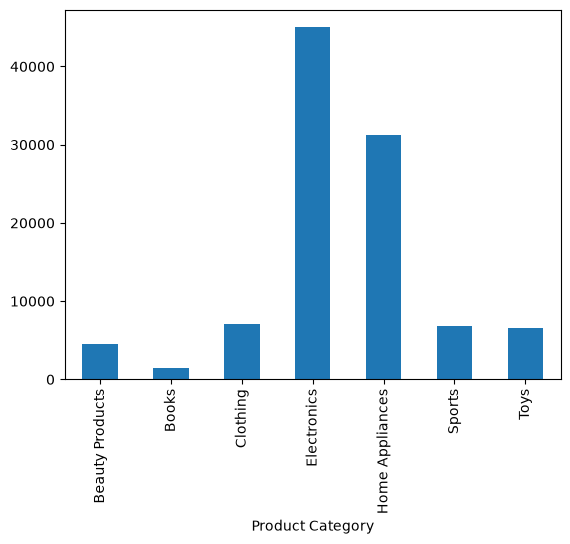

In [66]:
sales.groupby('Product Category')['Total Revenue'].sum().plot(kind='bar')